In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
dfj= pd.read_csv(r"C:\Users\Lala\Downloads\archive\2020-Jan.csv")

In [4]:
dff=pd.read_csv(r"C:\Users\Lala\Downloads\archive\2020-Feb.csv")

In [9]:
dfj.shape

(4264752, 9)

In [10]:
dff.shape

(4156682, 9)

In [5]:
df= pd.concat([dfj,dff])

## Setirlerin concat edilmesi

In [13]:
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-01-01 00:00:00 UTC,view,5809910,1602943681873052386,NaN,grattol,5.24,595414620,4adb70bb-edbd-4981-b60f-a05bfd32683a
1,2020-01-01 00:00:09 UTC,view,5812943,1487580012121948301,NaN,kinetics,3.97,595414640,c8c5205d-be43-4f1d-aa56-4828b8151c8a
2,2020-01-01 00:00:19 UTC,view,5798924,1783999068867920626,NaN,zinger,3.97,595412617,46a5010f-bd69-4fbe-a00d-bb17aa7b46f3
3,2020-01-01 00:00:24 UTC,view,5793052,1487580005754995573,NaN,NaN,4.92,420652863,546f6af3-a517-4752-a98b-80c4c5860711
4,2020-01-01 00:00:25 UTC,view,5899926,2115334439910245200,NaN,NaN,3.92,484071203,cff70ddf-529e-4b0c-a4fc-f43a749c0acb
...,...,...,...,...,...,...,...,...,...
4156677,2020-02-29 23:59:32 UTC,view,5885416,1487580005092295511,NaN,grattol,6.27,622082947,fb29909b-6ef5-4662-b4ee-288e73e5dc10
4156678,2020-02-29 23:59:39 UTC,cart,5550686,1487580008145748965,NaN,NaN,1.11,459705611,05d2add3-01f7-47ee-8364-27341673227f
4156679,2020-02-29 23:59:45 UTC,view,5850628,1602943681873052386,NaN,grattol,5.24,622090043,ab7d349f-db5d-4790-8ab1-31e5c894459d
4156680,2020-02-29 23:59:54 UTC,view,5716351,1487580010872045658,NaN,irisk,0.79,619841242,18af673b-7fb9-4202-a66d-5c855bc0fd2d


In [14]:
event_distribution= df['event_type'].value_counts()

In [15]:
event_distribution

event_type
view                3991194
cart                2297017
remove_from_cart    1627433
purchase             505790
Name: count, dtype: int64

## The funnel

In [16]:
view_users = set(df.loc[df['event_type'] == 'view', 'user_id'] .dropna().unique())
cart_users = set( df.loc[df['event_type'] == 'cart', 'user_id'].dropna().unique())
purchase_users = set(df.loc[df['event_type'] == 'purchase', 'user_id'].dropna().unique())


In [17]:
funnel = pd.DataFrame({ 'Stage': ['Viewed','Added to Cart','Purchased'],
    'Unique Users': [
        len(view_users),
        len(cart_users),
        len(purchase_users)]})

In [18]:
funnel

,Stage,Unique Users
0,Viewed,716987
1,Added to Cart,162035
2,Purchased,49473


##  conversion rates

In [19]:
view_to_cart = len(cart_users) / len(view_users) * 100
cart_to_purchase = len(purchase_users) / len(cart_users) * 100
view_to_purchase = len(purchase_users) / len(view_users) * 100

In [22]:
view_to_cart

22.599433462531398

In [23]:
cart_to_purchase

30.532292405961677

In [24]:
view_to_purchase

6.900125106870836

## Funnel by category — Top 8

In [25]:
top_categories = ( df[df['event_type'] == 'view'].dropna(subset=['category_code'])['category_code'].value_counts().head(8))

In [26]:
top_categories

category_code
appliances.environment.vacuum      48522
furniture.living_room.cabinet      10670
apparel.glove                      10584
stationery.cartrige                 8503
accessories.bag                     7220
furniture.bathroom.bath             6923
appliances.personal.massager        2822
appliances.personal.hair_cutter     2252
Name: count, dtype: int64

In [28]:
category_results = []
for category in top_categories.index:
    category_df = df[df['category_code'] == category]
    views = category_df.loc[category_df['event_type'] == 'view','user_id' ].nunique()

    carts = category_df.loc[category_df['event_type'] == 'cart','user_id'].nunique()
    purchases = category_df.loc[category_df['event_type'] == 'purchase', 'user_id'].nunique()

    category_results.append({
        'category_code': category,
        'view_users': views,
        'cart_users': carts,
        'purchase_users': purchases,
        'view_to_cart_%': carts / views * 100,
        'cart_to_purchase_%': purchases / carts * 100,
        'view_to_purchase_%': purchases / views * 100})

category_funnel = pd.DataFrame(category_results)

In [29]:
category_funnel

,category_code,view_users,cart_users,purchase_users,view_to_cart_%,cart_to_purchase_%,view_to_purchase_%
0,appliances.environment.vacuum,15431,3883,1366,25.163632,35.178985,8.852310
1,furniture.living_room.cabinet,5377,760,119,14.134276,15.657895,2.213130
2,apparel.glove,4965,4128,1932,83.141994,46.802326,38.912387
3,stationery.cartrige,4313,2265,1025,52.515650,45.253863,23.765361
4,accessories.bag,3147,146,45,4.639339,30.821918,1.429933
5,furniture.bathroom.bath,3602,1164,384,32.315380,32.989691,10.660744
6,appliances.personal.massager,1335,151,35,11.310861,23.178808,2.621723
7,appliances.personal.hair_cutter,1141,113,28,9.903593,24.778761,2.453988


## Compare January vs February

In [35]:
dfj['month'] = 'January'
dff['month'] = 'February'

In [36]:
df = pd.concat([dfj, dff])

In [37]:
monthly_results = []

for month, month_df in df.groupby('month'):

    views = month_df.loc[month_df['event_type'] == 'view', 'user_id' ].nunique()

    carts = month_df.loc[month_df['event_type'] == 'cart','user_id' ].nunique()

    purchases = month_df.loc[month_df['event_type'] == 'purchase','user_id'].nunique()

    monthly_results.append({
        'month': month,
        'view_users': views,
        'cart_users': carts,
        'purchase_users': purchases,
        'view_to_cart_%': carts / views * 100,
        'cart_to_purchase_%': purchases / carts * 100,
        'view_to_purchase_%': purchases / views * 100})

monthly_funnel = pd.DataFrame(monthly_results)

In [39]:
monthly_funnel

,month,view_users,cart_users,purchase_users,view_to_cart_%,cart_to_purchase_%,view_to_purchase_%
0,February,379246,89269,25759,23.538548,28.855482,6.792161
1,January,397775,92653,28220,23.292816,30.457729,7.094463


# Overall baxdıqda yanvarda 6,79 olub, fevralda isə 7,09. Yəni dəyişim -0,3 dür. Convertion rate yaxşılaşmayıb. Əksinə dahada pisləşib

##  Top 10 brands by purchase count

In [40]:
top_brands = (df[df['event_type'] == 'purchase'].dropna(subset=['brand'])['brand'].value_counts().head(10))

In [41]:
top_brands

brand
runail       45274
irisk        31210
grattol      21320
masura       19929
ingarden     10276
estel         8616
bpw.style     8437
uno           6871
italwax       6740
kapous        6370
Name: count, dtype: int64

In [42]:
brand_results = []

for brand in top_brands.index:
    brand_df = df[df['brand'] == brand]
    view_users = brand_df.loc[brand_df['event_type'] == 'view','user_id' ].nunique()
    purchase_users = brand_df.loc[brand_df['event_type'] == 'purchase','user_id'].nunique()
    brand_results.append({
        'brand': brand,
        'purchase_count': top_brands[brand],
        'view_users': view_users,
        'purchase_users': purchase_users,
        'view_to_purchase_%': purchase_users / view_users * 100})

brand_funnel = pd.DataFrame(brand_results)

In [43]:
brand_funnel

,brand,purchase_count,view_users,purchase_users,view_to_purchase_%
0,runail,45274,86823,15562,17.923822
1,irisk,31210,70510,13332,18.907956
2,grattol,21320,48870,7905,16.175568
3,masura,19929,35640,5401,15.154321
4,ingarden,10276,23716,4972,20.964750
5,estel,8616,40234,3994,9.926927
6,bpw.style,8437,13376,3070,22.951555
7,uno,6871,22313,4128,18.500426
8,italwax,6740,19923,2927,14.691563
9,kapous,6370,42289,3018,7.136608


## Outliers

In [44]:
purchase_prices = df.loc[df['event_type'] == 'purchase','price'].dropna()

Q1 = purchase_prices.quantile(0.25)
Q3 = purchase_prices.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[ (df['event_type'] == 'purchase') & ((df['price'] < lower_bound) |(df['price'] > upper_bound) )]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Outliers:", len(outliers))

Q1: 1.59
Q3: 5.56
IQR: 3.9699999999999998
Lower bound: -4.365
Upper bound: 11.515
Outliers: 34947


# VIZUAL 1:

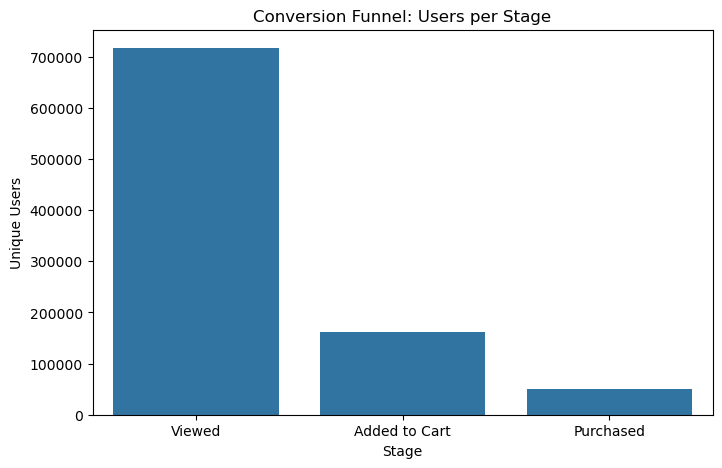

In [46]:
plt.figure(figsize=(8, 5))
sns.barplot(data=funnel, x='Stage', y='Unique Users')
plt.title('Conversion Funnel: Users per Stage')
plt.xlabel('Stage')
plt.ylabel('Unique Users')
plt.show()

## VIZUAL 2:

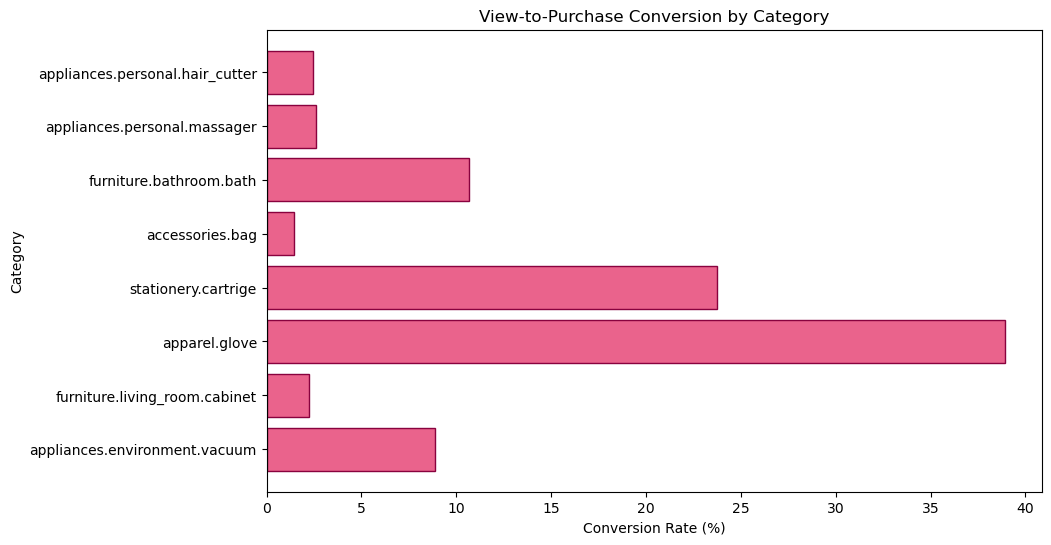

In [55]:
plt.figure(figsize=(10, 6))

plt.barh( category_funnel['category_code'],category_funnel['view_to_purchase_%'],color='#ea638c',edgecolor='#89023e')

plt.title('View-to-Purchase Conversion by Category')
plt.xlabel('Conversion Rate (%)')
plt.ylabel('Category')
plt.show()

# VIZUAL 3:

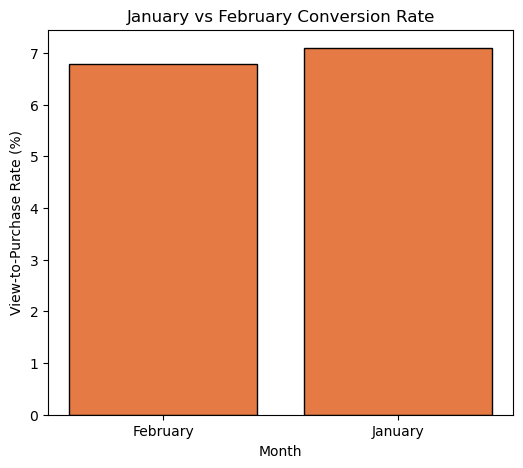

In [54]:
plt.figure(figsize=(6, 5))
plt.bar( monthly_funnel['month'],monthly_funnel['view_to_purchase_%'],color='#e57a44',edgecolor='black')
plt.title('January vs February Conversion Rate')
plt.xlabel('Month')
plt.ylabel('View-to-Purchase Rate (%)')
plt.show()

# VIZUAL 4:

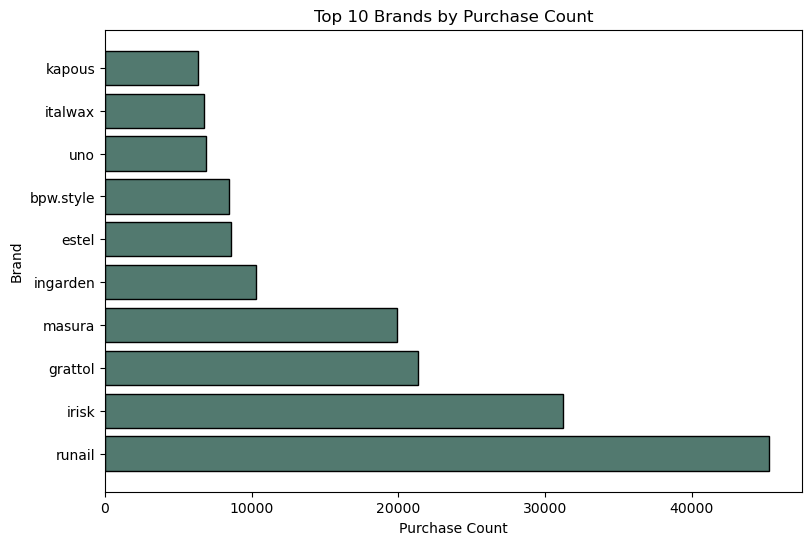

In [53]:
plt.figure(figsize=(9, 6))
plt.barh(brand_funnel['brand'], brand_funnel['purchase_count'],color='#52796f',edgecolor='black')
plt.title('Top 10 Brands by Purchase Count')
plt.xlabel('Purchase Count')
plt.ylabel('Brand')
plt.show()

# BONUS 1:

In [8]:
df['event_time'] = pd.to_datetime(df['event_time'])

In [9]:
v = df[df.event_type == 'view'].groupby('user_id').event_time.min()
p = df[df.event_type == 'purchase'].groupby('user_id').event_time.min()

time = (p - v).dropna()

In [10]:
print("Average time:", time.mean())

Average time: 5 days 01:31:07.115813725


# BONUS 2:

In [11]:
products = df.groupby(['product_id', 'event_type']).user_id.nunique().unstack(fill_value=0)
products['conversion_%'] = products['purchase'] / products['view'] * 100
products = products[products['view'] >= 500].sort_values( 'conversion_%').head(20)

In [12]:
products

event_type,cart,purchase,remove_from_cart,view,conversion_%
product_id,,,,,
27759,0,0,2,712,0.000000
5678162,0,0,0,553,0.000000
5915337,34,5,7,4818,0.103778
5688835,25,1,11,792,0.126263
5867160,30,1,14,541,0.184843
5877528,16,1,13,519,0.192678
5646091,12,1,3,518,0.193050
5888096,14,1,4,503,0.198807
5805511,44,2,21,1004,0.199203
